<a href="https://colab.research.google.com/github/kostetskavv/ml_course_homeworks/blob/main/HW_2_1_%D0%90%D0%BD%D0%B0%D0%BB%D1%96%D0%B7_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA_%D0%B4%D0%BB%D1%8F_%D0%BF%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B8_%D0%BB%D1%96%D0%BD%D1%96%D0%B8%CC%86%D0%BD%D0%BE%D1%96%CC%88_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%96%CC%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [52]:
import pandas as pd

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
medical_df = pd.read_csv("drive/MyDrive/ML course data/medical-charges.csv")


In [55]:
medical_df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


1. Можна було б провести кореляційний аналіз між цільовою числовою колонкою `charges` та іншими числовими колонками: `age`, `bmi`, `children`. Це дасть можливість зрозуміти, які числові фактори впливають на наше `charges`. Можна побудувати графіки розсіювання або порахувати коефіцієнт кореляції Пірсона
2. Говорячи про кореляцію, також можна було б провести кореляційний аналіз між парою категоріальних змінних, скажімо, `sex`, `smoker` і числовою `charges` (побудувати боксплоти)
3. Ну і провести аналіз взаємозалежностей категоріальних змінних у відношенні до цільової. Це допоможе виявити важливі перехресні ефекти, які можуть бути критично важливими для прогнозування.


**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [56]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

In [57]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

Можемо побачити, що медіани для обох статей дуже близькі
Однак для чоловіків суттєво більший розмах значень, ніж у жінок. Тобто в чоловіків зустрічаються значно вищі значення `charges`  
По гістограмі можемо побачити, що дані досить рівномірно розподілені між статями, бо в бінах приблизно однакова кількість жінок та чоловіків (з деякими виключеннями).

In [58]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

В даному випадку теж маємо цікаві візуалізації. Медіани, особливо для регіонів `southwest` і `northwest`, знаходятся приблизно в одному діапазоні.
Також, в діапазоні від 2 000 до 14 000 доларів спостерігається приблизно рівномірний розподіл спостережень між регіонами

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [59]:
medical_df.region.value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [60]:
px.histogram(medical_df, x='region', color='smoker', title='Region')

Бачимо, що частка курців у кожному з регіонів становить малу частину всіх клієнтів. Навіть можна сказати, що вона приблизно однакова, за виключенням `southeast` регіону, де вона трохи більша  
Розподіли курців/некурців за регіонами виглядають рівномірними. Тож можемо зробити висновок, що регіон не має суттєвого впливу на ймовірність куріння

In [61]:
medical_df.children.value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [62]:
px.histogram(medical_df, x='children', color='smoker', title='Children')

Бачимо, що в більшості клієнтів немає дітей, і саме серед цієї категорії найбільша частка курців  
Бачимо поступове зменшення кількості клієнтів зі збільшенням дітей, як і зменшення частки курців в цих групах. Наявність більше, ніж трьох дітей є нетиповою, але в нас також і мало спостережень по цим групам, як і стосовно факту, чи є серед них курці

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [63]:
fig = px.violin(medical_df,
                x='children',
                y='charges',
                color='smoker',
                hover_data=['sex'],
                title='Children vs. Charges')

fig.update_traces(marker_size=3, jitter=0.3, width=0.6)  # ширше і з розкидом
fig.update_layout(width=900, height=500)
fig.show()

В цілому, можна сказати, що `charges` слабо залежить від кількості дітей у клієнта, бо розподіли по категоріям є доволі схожими.  
Натомість з приводу куріння можемо зробити висновок, що страхові витрати клієнтів-некурців значно менші. Бачимо довгі хвостики вгорі для категорії курців, що свідчить про наявність клієнтів з дуже високими витратами, але ці дані мають великий розкид та натомість малу щільність, бо спостережень доволі мало

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [64]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [65]:
def estimate_charges(age, w, b):
    return w * age + b

In [66]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])
    plt.show();

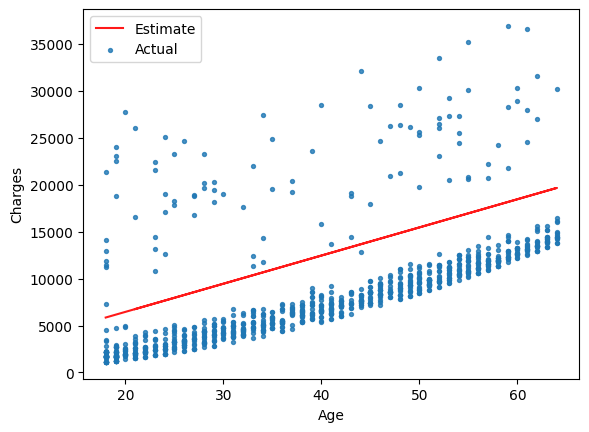

In [67]:
try_parameters(non_smoker_df, 300, 450)

Бачимо, що кут нахилу вийшов непоганий, але краще узяти трохи менший, і необхідно підібрати параметр `b` такий, щоб лінія опустилася нижче

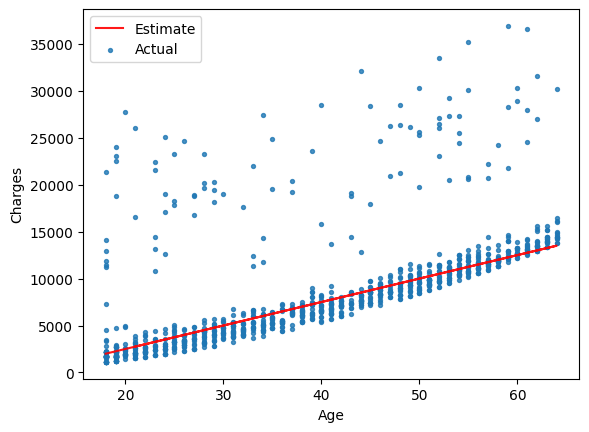

In [68]:
try_parameters(non_smoker_df, 250, -2500)

Ця пряма вже краща, потрапила на наші дані, але знову можна спробувати наблизити ще. Спробуємо зменшити `b` ще трохи

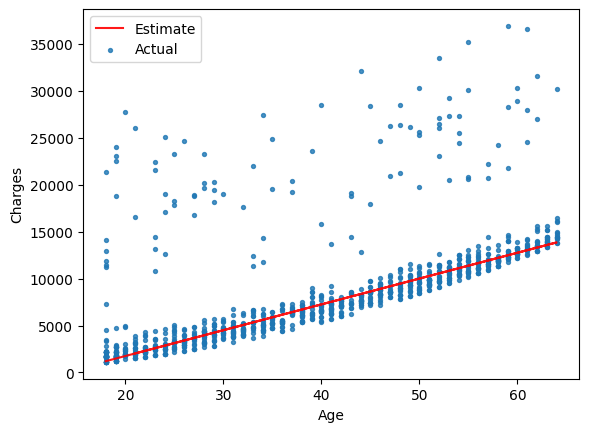

In [69]:
try_parameters(non_smoker_df, 275, -3750)

Ця пряма виглядає набагато краще

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [70]:
import numpy as np

In [71]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [72]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

In [73]:
w = 300
b = 450

RMSE Loss:  6052.323767914164


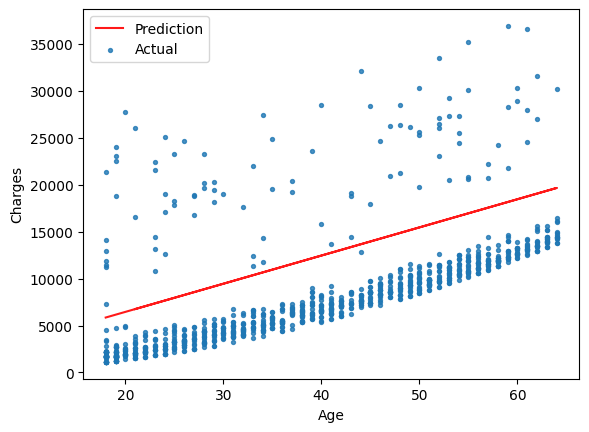

In [74]:
try_parameters(w, b)

In [75]:
w = 250
b = -2500

RMSE Loss:  4793.904061890193


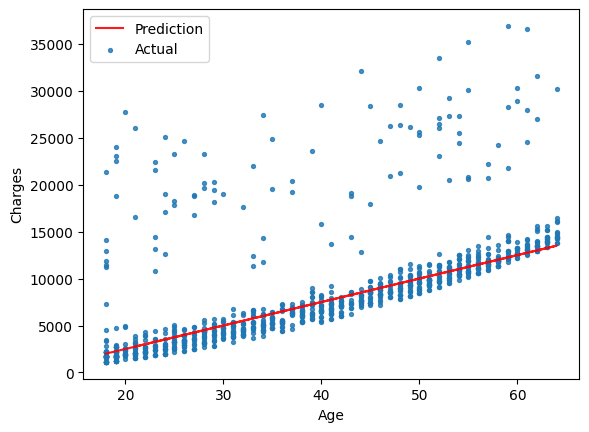

In [76]:
try_parameters(w, b)

In [77]:
w = 275
b = -3750

RMSE Loss:  4856.159664144842


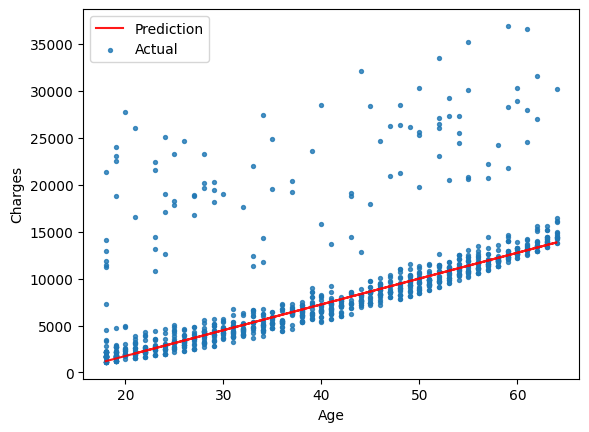

In [78]:
try_parameters(w, b)

Хоча візуально здавалося, що остання пара параметрів дає найкраще наближення, за результатами розрахунків RMSE, ми можемо побачити, що змогли досягнути найнижчого значення втрат за параметрів `w = 250`, `b = -2500`  
Для ручного підбору параметрів можна було б діяти наступним чином:
1. Обрати випадкові параметри, побудувати криву та порахувати помилку
2. Змінити трохи якийсь з параметрів та порахувати помилку з цим урахуванням
3. Якщо помилка збільшилася, то спробувати змінити параметр у протилежний бік та порахувати помилку ще раз
4. Якщо вона почала зменшуватися, то рухатися в цьому напрямку далі до бажаного наближення